## LogisticRegression
逻辑斯蒂回归(LogisticRegression)是一个重要的分类模型，该算法将线性回归的输出概率化，根据“概率”进行分类

实验要求：
1. 实现LogisticRegression
2. 使用不同的初始化theta、学习率alpha、训练轮数iterations来训练模型。绘制cost曲线、输出准确率进行观察。

In [1]:
import math
import numpy as np
import pandas as pd
from pandas import DataFrame
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from pylab import scatter, show, legend, xlabel, ylabel
from numpy import where
import matplotlib.pyplot as plt
import os

#### 1. 导入数据：学科成绩为特征的二分类问题

In [2]:
df = pd.read_csv("data.csv", header=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   grade1     100 non-null    float64
 1   grade2     100 non-null    float64
 2   label;;;;  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [3]:
df.columns = ["grade1","grade2","label"]
#df的第三个列名有；；；
x = df["label"].map(lambda x: float(x.rstrip(';')))
X = df[["grade1","grade2"]]
X = np.array(X)
print(X)
#数据min_max归一化到（-1，1）间 
min_max_scaler = preprocessing.MinMaxScaler(feature_range=(-1,1))
X = min_max_scaler.fit_transform(X)
#数据集label中有；；；；要去掉
Y = df["label"].map(lambda x: float(x.rstrip(';')))
Y = np.array(Y)
print(Y)
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.33, random_state=0)

[[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]
 [45.08327748 56.31637178]
 [61.10666454 96.51142588]
 [75.02474557 46.55401354]
 [76.0987867  87.42056972]
 [84.43281996 43.53339331]
 [95.86155507 38.22527806]
 [75.01365839 30.60326323]
 [82.30705337 76.4819633 ]
 [69.36458876 97.71869196]
 [39.53833914 76.03681085]
 [53.97105215 89.20735014]
 [69.07014406 52.74046973]
 [67.94685548 46.67857411]
 [70.66150955 92.92713789]
 [76.97878373 47.57596365]
 [67.37202755 42.83843832]
 [89.67677575 65.79936593]
 [50.53478829 48.85581153]
 [34.21206098 44.2095286 ]
 [77.92409145 68.97235999]
 [62.27101367 69.95445795]
 [80.19018075 44.82162893]
 [93.1143888  38.80067034]
 [61.83020602 50.25610789]
 [38.7858038  64.99568096]
 [61.37928945 72.80788731]
 [85.40451939 57.05198398]
 [52.10797973 63.12762377]
 [52.04540477 69.43286012]
 [40.23689374 71.16774802]
 [54.63510555 52.21388588]
 [33.91550011 98.86943574]
 

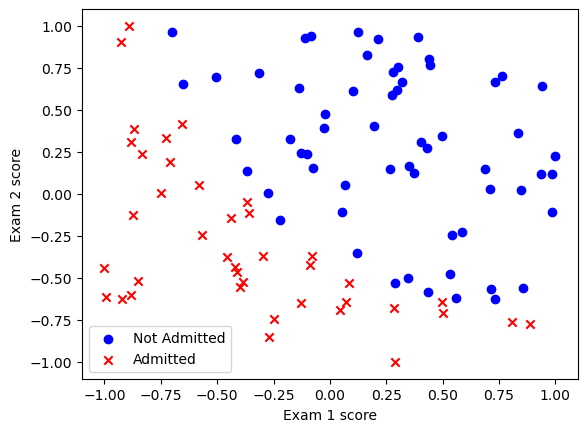

In [4]:
# 可视化
pos = where(Y == 1)
neg = where(Y == 0)
scatter(X[pos, 0], X[pos, 1], marker='o', c='b')
scatter(X[neg, 0], X[neg, 1], marker='x', c='r')
xlabel('Exam 1 score')
ylabel('Exam 2 score')
legend(['Not Admitted', 'Admitted'])
show()

#### 2. 设定拟合函数（Hypothesis Function）

逻辑斯蒂回归将线性回归拟合函数的输出通过Sigmoid函数映射到概率区间[0,1]，利用概率构造二分类模型（实际上是分类模型）

线性回归函数： $z=\theta^Tx$

Sigmoid函数： $g(z) = \frac{1}{1+e^{-z}}$

<img src="./attachments/sigmoid.png">

逻辑斯蒂拟合函数(Hypothesis Function)：$h_\theta(x) = \frac{1}{1+e^{-\theta^Tx}}$

In [5]:
#构造逻辑斯蒂拟合函数
def Sigmoid(z):
    """
    Sigmoid函数：输入为线性回归函数值
    """
    sig_z = 1 / (1 + np.exp(-z))
    return sig_z 

def Hypothesis(theta, x):
    """
    逻辑斯蒂拟合函数：线性回归函数和Sigmoid函数的复合
    输入：theta(线性回归学习权重，与数据的维度相同)、x(数据)
    输出：Sigmoid(z)（拟合函数）(z为线性回归函数)
    """
    z = np.dot(x, theta)
    return Sigmoid(z)

#### 3. 设定代价函数（Cost Function）
线性回归的代价函数（均方误差）对于sigmoid()是非凸的,容易使优化落入局部极小值。
因此借鉴概率论中极大似然估计的思想，选用以下代价函数，可保证优化的效果： 

<img src="./attachments/costfun1.png">

该式可写为：

<img src="./attachments/costfun2.png">

可以看出，这样的代价函数在y=1的前提下，如果预测值越接近1，那么相应代价就越小，反之则越大（对于y=0亦然）

设m为样本数：

<img src="./attachments/costfun3.png">


In [6]:
def Cost_Function(X,Y,theta):
    """
    代价函数：按标签对每个样本的“损失”进行累加并平均
    输入：X（数据）、Y（标签）、theta(当前theta)
    输出：J（损失函数值）
    """
    J = 0
    m = len(Y)
    for i in range(m):
        h = Hypothesis(theta, X[i])
        J += -Y[i] * np.log(h) - (1 - Y[i]) * np.log(1 - h)
    J /= m
    return J

#### 4. 对代价函数进行梯度下降优化Theta
关于Theta中的第j个权重$\theta_j$,其一轮的梯度下降更新为：$\theta_j^{'} = \theta_j-\frac{\alpha}{m} \sum_{i=1}^m(h_\theta(x^{(i)}-y^{(i)})x_j^{(i)}$

In [ ]:
def Gradient_Descent(X,Y,theta,alpha):
    """
    一轮梯度下降更新theta
    输入：X（数据）、Y（标签）、theta(当前theta，要被更新)、alpha（学习率）
    输出：new_theta（更新的theta）
    """
    theta = np.array(theta, dtype=float)
    m = len(Y)
    h = Sigmoid(np.dot(X, theta))              
    gradient = np.dot(X.T, (h - Y)) / m         
    new_theta = theta - alpha * gradient
    return new_theta

#### 5. LogisticRegression 训练

In [21]:
def Logistic_Regression(X,Y,alpha,theta,num_iters):
    """
    多轮迭代梯度下降
    输入：X（数据）、Y（标签）、theta(初始化的theta)、alpha（学习率）、num_iters（迭代梯度下降的轮数）
    输出：theta（最终学习得到的theta）、epoch_loss（各轮cost值（有间隔的取样）组成的list,用于绘制cost曲线图）
    """
    epoch_loss = []
    for i in range(num_iters):
        theta = Gradient_Descent(X, Y, theta, alpha)
        if i % 50 == 0:
            cost = Cost_Function(X, Y, theta)
            epoch_loss.append(cost)
            print(f"Iteration {i}: Cost {cost}")
    return theta, epoch_loss 

In [22]:
#超参数设置与初始化
initial_theta = [0,0] #学习参数初始化
alpha = 0.1 #学习率
iterations = 1000 #训练轮数

# 训练
#opt_theta为最终学习到的模型参数theta
opt_theta, epoch_loss = Logistic_Regression(X_train,Y_train,alpha,initial_theta,iterations)

Iteration 0: Cost 0.6883702453033198
Iteration 50: Cost 0.5245732802393733
Iteration 100: Cost 0.44342474512823316
Iteration 150: Cost 0.39671149591346805
Iteration 200: Cost 0.36655750528740505
Iteration 250: Cost 0.34549239021521033
Iteration 300: Cost 0.32993666109900327
Iteration 350: Cost 0.31797481948502443
Iteration 400: Cost 0.30849065724440505
Iteration 450: Cost 0.3007892889282955
Iteration 500: Cost 0.294414950787566
Iteration 550: Cost 0.28905589852903885
Iteration 600: Cost 0.2844914348398625
Iteration 650: Cost 0.28056077675231883
Iteration 700: Cost 0.27714391905678876
Iteration 750: Cost 0.27414941643334717
Iteration 800: Cost 0.2715063254402201
Iteration 850: Cost 0.26915873875151713
Iteration 900: Cost 0.26706198578272633
Iteration 950: Cost 0.2651799340980293


#### 6. 模型评估与绘制cost曲线 

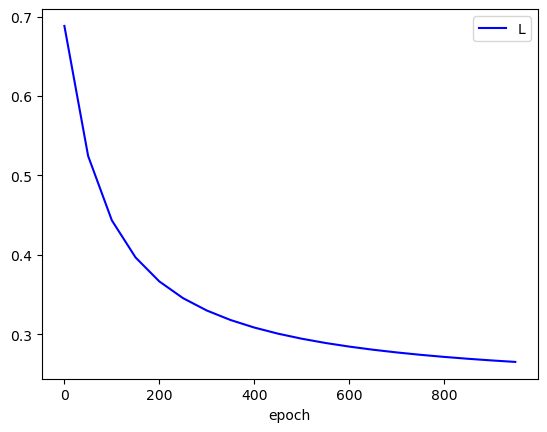

<Figure size 640x480 with 0 Axes>

In [23]:
def cost_plot(epoch_losses, iterations, figure_name, imgPath = "./"):
    # plt.switch_backend('Agg') 
    plt.figure() 
    x = list(range(0,iterations,50))
    plt.plot(x, epoch_losses,'b',label = 'loss')
    plt.xlabel('epoch')
    plt.legend('Logistic Regression')
    plt.show()        
    plt.savefig(os.path.join(imgPath,figure_name))
    
figure_name = "0_recon_loss.jpg"    
cost_plot(epoch_loss,iterations,figure_name)

In [24]:
def evaluation(X_test,Y_test,theta):
    length = len(X_test)
    score = 0
    for i in range(length):
        prediction = round(Hypothesis(X_test[i],theta))#用round函数四舍五入，将概率映射到标签
        answer = Y_test[i]
        if prediction == answer:
            score += 1
    score = float(score) / float(length)
    print('Accuracy = ',score)

evaluation(X_test,Y_test,opt_theta)

Accuracy =  0.8787878787878788


#### 7. 使用不同的初始化theta、学习率alpha、训练轮数iterations来训练模型。绘制cost曲线、输出准确率进行观察。

Iteration 0: Cost 0.6789330240730558
Iteration 50: Cost 0.3945773239962291
Iteration 100: Cost 0.3290155820289363
Iteration 150: Cost 0.3002678242815123
Iteration 200: Cost 0.2841543051441334
Iteration 250: Cost 0.2739137589288224
Iteration 300: Cost 0.26688856839070674
Iteration 350: Cost 0.2618145416360484
Iteration 400: Cost 0.25801148294248294
Iteration 450: Cost 0.255080326183557
Iteration 500: Cost 0.2527713995331065
Iteration 550: Cost 0.25092054755392973
Iteration 600: Cost 0.24941549144238387
Iteration 650: Cost 0.24817692361381047
Iteration 700: Cost 0.2471473093079585
Iteration 750: Cost 0.24628395883660267
Iteration 800: Cost 0.24555458243461797
Iteration 850: Cost 0.24493434787880475
Iteration 900: Cost 0.24440387981798373
Iteration 950: Cost 0.24394786719597544
Iteration 1000: Cost 0.24355407377711966
Iteration 1050: Cost 0.24321262214351255
Iteration 1100: Cost 0.24291546707630415
Iteration 1150: Cost 0.2426560025252861
Iteration 1200: Cost 0.24242876438352726
Iteration 

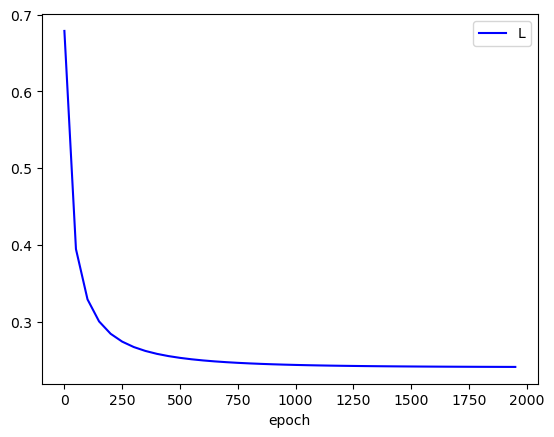

Accuracy =  0.8787878787878788


<Figure size 640x480 with 0 Axes>

In [26]:
# 1.
initial_theta = [0,0] #学习参数初始化
alpha = 0.3 #学习率
iterations = 2000 #训练轮数
opt_theta, epoch_loss = Logistic_Regression(X_train,Y_train,alpha,initial_theta,iterations)
cost_plot(epoch_loss,iterations,figure_name)
evaluation(X_test,Y_test,opt_theta)

Iteration 0: Cost 0.5813096334025072
Iteration 50: Cost 0.3306410638622234
Iteration 100: Cost 0.28901591503874396
Iteration 150: Cost 0.27144631505177624
Iteration 200: Cost 0.2618959778255498
Iteration 250: Cost 0.25602638339459977
Iteration 300: Cost 0.25214042653310076
Iteration 350: Cost 0.24943561456671207
Iteration 400: Cost 0.24748389524300565
Iteration 450: Cost 0.24603687782325598
Iteration 500: Cost 0.2449411531178077
Iteration 550: Cost 0.24409731382882124
Iteration 600: Cost 0.24343844519779703
Iteration 650: Cost 0.24291809100242792
Iteration 700: Cost 0.24250316451712509
Iteration 750: Cost 0.24216959094807952
Iteration 800: Cost 0.24189953148155194
Iteration 850: Cost 0.24167956029330495
Iteration 900: Cost 0.2414994356114994
Iteration 950: Cost 0.24135125216326178
Iteration 1000: Cost 0.24122884485161822
Iteration 1050: Cost 0.24112736172138838
Iteration 1100: Cost 0.24104295331770528
Iteration 1150: Cost 0.24097254352060304
Iteration 1200: Cost 0.24091365834225537
Ite

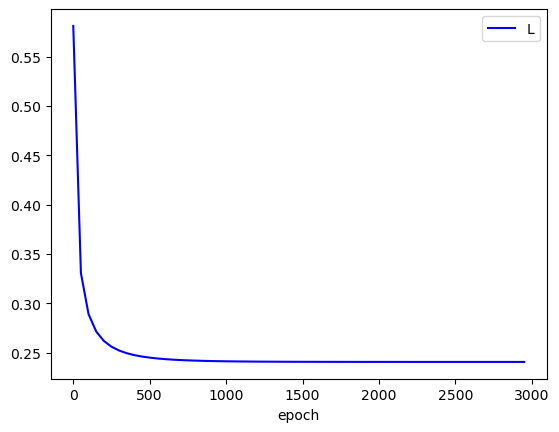

Accuracy =  0.8787878787878788


<Figure size 640x480 with 0 Axes>

In [28]:
# 2. 
initial_theta = [0,1] #学习参数初始化
alpha = 0.5 #学习率
iterations = 3000 #训练轮数
opt_theta, epoch_loss = Logistic_Regression(X_train,Y_train,alpha,initial_theta,iterations)
cost_plot(epoch_loss,iterations,figure_name)
evaluation(X_test,Y_test,opt_theta)

Iteration 0: Cost 0.5436098947003517
Iteration 50: Cost 0.30945303179754985
Iteration 100: Cost 0.27435466117900126
Iteration 150: Cost 0.26061764662174625
Iteration 200: Cost 0.25357968937477104
Iteration 250: Cost 0.24947010364274297
Iteration 300: Cost 0.246875861868593
Iteration 350: Cost 0.24515114804637686
Iteration 400: Cost 0.2439615063913688
Iteration 450: Cost 0.24311811679389964
Iteration 500: Cost 0.24250742668915307
Iteration 550: Cost 0.2420577784990529
Iteration 600: Cost 0.2417222097837141
Iteration 650: Cost 0.24146899355986773
Iteration 700: Cost 0.24127615687220944
Iteration 750: Cost 0.24112816558622213
Iteration 800: Cost 0.2410138463668173
Iteration 850: Cost 0.24092504416139954
Iteration 900: Cost 0.2408557321401959
Iteration 950: Cost 0.24080140829090246
Iteration 1000: Cost 0.24075867833413483
Iteration 1050: Cost 0.24072496249331335
Iteration 1100: Cost 0.24069828624141623
Iteration 1150: Cost 0.2406771289949412
Iteration 1200: Cost 0.24066031342388783
Iterati

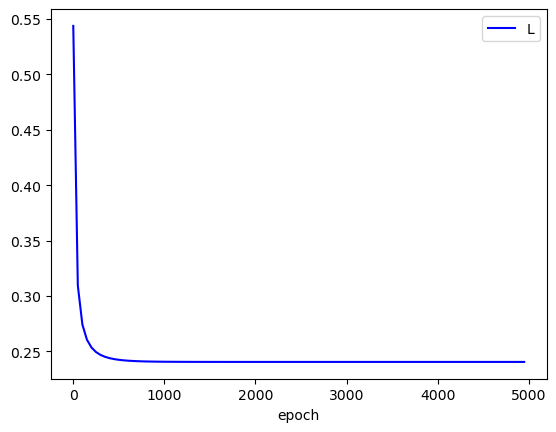

Accuracy =  0.8787878787878788


<Figure size 640x480 with 0 Axes>

In [27]:
# 3.
initial_theta = [1,0] #学习参数初始化
alpha = 0.7 #学习率
iterations = 5000 #训练轮数
opt_theta, epoch_loss = Logistic_Regression(X_train,Y_train,alpha,initial_theta,iterations)
cost_plot(epoch_loss,iterations,figure_name)
evaluation(X_test,Y_test,opt_theta)